<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/ML/XGBoost_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Градієнтний бустинг: XGBoost і LightGBM

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# ---------- Датасет: ВІДТІК (класифікація) ----------
m = 1500
tenure  = np.random.randint(1, 72, m)
monthly = np.random.normal(70, 25, m).clip(15, 150)
support = np.random.poisson(1.5, m)
age     = np.random.randint(18, 75, m)
contract = np.random.choice(["місячний", "річний", "дворічний"], m, p=[.5, .3, .2])
contract_risk = pd.Series({"місячний": .8, "річний": -.3, "дворічний": -.8})

risk = (-0.05*tenure + 0.02*monthly + 0.45*support - 0.01*age
        + contract_risk[contract].values + np.random.normal(0, .7, m))
prob = 1/(1+np.exp(-(risk-0.5)))
churn = (np.random.rand(m) < prob).astype(int)

cust = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1), "support": support,
    "age": age, "contract": contract, "churn": churn,
})

print("Частка відтоку:", f"{cust['churn'].mean():.1%}")
cust

Частка відтоку: 43.2%


,tenure,monthly,support,age,contract,churn
0,52,82.1,2,42,дворічний,1
1,15,59.5,5,69,дворічний,1
2,61,98.3,3,71,річний,0
3,21,63.1,0,41,місячний,1
4,24,104.6,5,74,місячний,1
...,...,...,...,...,...,...
1495,28,104.6,5,42,річний,1
1496,35,68.9,2,73,місячний,0
1497,61,118.3,0,48,річний,0
1498,54,67.5,3,54,місячний,0


## Pipelines

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score


X = cust[['tenure', 'monthly', 'support', 'age', 'contract']]
y = cust['churn']

num_cols = ['tenure', 'monthly', 'support', 'age']
cat_cols = ['contract']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

pipe.fit(X_train, y_train)
print('Accuracy на тесті:', round(pipe.score(X_test, y_test), 3))

Accuracy на тесті: 0.74


In [35]:
cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'CV accuracy: {np.round(cv, 3)} | середнє: {cv.mean():.3f} ± {cv.std():.3f}')

CV accuracy: [0.767 0.747 0.683 0.74  0.747] | середнє: 0.737 ± 0.028


> Інтуїція: "команда, що виправляє помилки одне одного"


| | Random Forest | Градієнтний бустинг |
|---|---|---|
| Як будуються дерева | паралельно, незалежно | послідовно, кожне виправляє попередні |
| Логіка | усереднити багато думок | покроково зменшувати помилку |
| Точність на таблицях | висока | зазвичай **ще вища** |
| Ризик перенавчання | низький, прощає недогляд | вищий — потребує акуратного налаштування |

### Три головні гіперпараметри (решта - деталі)
- **`n_estimators`** - скільки дерев (скільки кроків виправлення).
- **`learning_rate`** - наскільки сильно кожне дерево коригує результат. Менше = обережніше й точніше, але треба більше дерев. Класичний компроміс: маленький `learning_rate` + багато дерев.
- **`max_depth`** - глибина кожного дерева. У бустингу тримають **невеликою** (3–6): дерева мають бути «слабкими», силу дає їх кількість.

In [36]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

X_tr = pd.get_dummies(X_train, columns=['contract'], dtype=int)
X_te = pd.get_dummies(X_test, columns=['contract'], dtype=int).reindex(columns=X_tr.columns, fill_value=0)

X_te.head()

,tenure,monthly,support,age,contract_дворічний,contract_місячний,contract_річний
599,62,52.6,1,50,0,0,1
1236,61,42.9,3,60,0,1,0
1452,49,77.1,0,18,0,1,0
334,5,80.5,2,26,1,0,0
123,42,16.1,3,52,0,1,0


In [37]:
models = {
    'Logisticsregression': pipe,
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE, verbose=-1)
}

rows = []
for name, mdl in models.items():
  if name == 'Logisticsregression':
    p = mdl.predict_proba(X_test)[:,1]
  else:
    mdl.fit(X_tr, y_train)
    p = mdl.predict_proba(X_te)[:,1]
  rows.append({
      'model': name,
      'accuracy': round(accuracy_score(y_test, (p >= 0.5).astype(int)), 3),
      'roc-auc': round(roc_auc_score(y_test, p), 3)
  })

pd.DataFrame(rows)


,model,accuracy,roc-auc
0,Logisticsregression,0.740,0.821
1,RandomForest,0.773,0.827
2,XGBoost,0.757,0.798
3,LightGBM,0.737,0.782


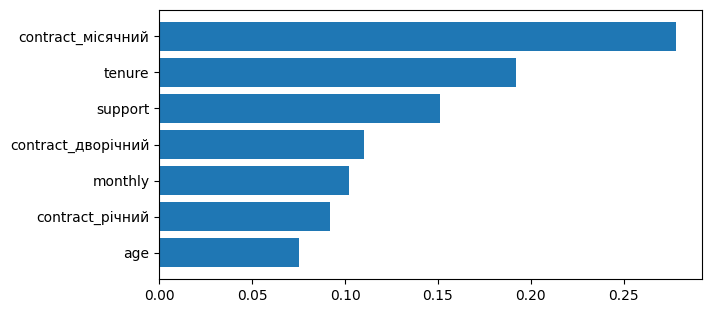

,feature,imp
5,contract_місячний,0.278
0,tenure,0.192
2,support,0.151
4,contract_дворічний,0.110
1,monthly,0.102
6,contract_річний,0.092
3,age,0.075


In [38]:
xgb = models['XGBoost']
imp = pd.DataFrame({
    'feature': X_tr.columns,
    'imp': xgb.feature_importances_.round(3)
}).sort_values('imp', ascending=False)

plt.figure(figsize=(7, 3.5))
plt.barh(imp['feature'], imp['imp']); plt.gca().invert_yaxis()
plt.show()
imp

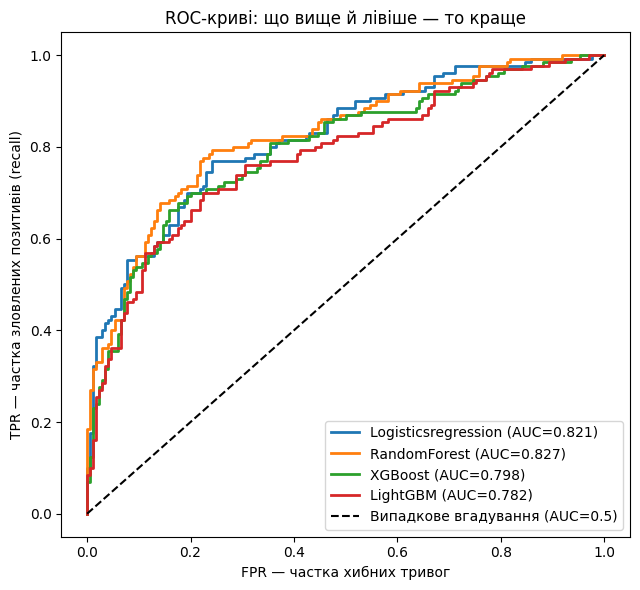

In [39]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(6.5, 6))
for name, mdl in models.items():
    p = (mdl.predict_proba(X_test)[:, 1] if name == "Logisticsregression"
         else mdl.predict_proba(X_te)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Випадкове вгадування (AUC=0.5)")
plt.xlabel("FPR — частка хибних тривог")
plt.ylabel("TPR — частка зловлених позитивів (recall)")
plt.title("ROC-криві: що вище й лівіше — то краще")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()